In [16]:
import importlib
import sys
sys.path.insert(0, '/glade/work/rneale/git/python-scripts/SONDE')

import skewt_utils as skutils
import raobs_utils as raobs
importlib.reload(skutils)
importlib.reload(raobs)

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print('Imports OK')

Imports OK


In [17]:
# ============================================================
# SETTINGS
# ============================================================

# --- Station ---
station   = 'Denver'        # any name in raobs.STATION_NAMES
dir_rdata = '/glade/work/rneale/data/raobs/'
dir_fig   = '/glade/u/home/rneale/python/python-figs/raobs/skewt/'
os.makedirs(dir_fig, exist_ok=True)

# --- Times to plot ---
target_times = [
    '2005-07-04 00:00',
    '2005-07-04 12:00',
]
max_hours = 3

# --- Level type for T/Td profile ---
# 'significant'  — up to 250 levels per sounding (more realistic curve)
# 'mandatory'    — 16 standard pressure levels only
lev_type = 'significant'

# --- Plot options ---
show_parcel    = True    # lift surface parcel; shade CAPE/CIN; mark LCL
show_hodograph = True    # hodograph inset (first sounding only)
p_top          = 50.     # upper pressure limit [hPa] — 50 hPa shows tropopause inversion

print(f'Station   : {station}')
print(f'Times     : {target_times}')
print(f'Lev type  : {lev_type}')
print(f'Parcel    : {show_parcel}   Hodograph: {show_hodograph}')
print(f'p_top     : {p_top} hPa')

Station   : Denver
Times     : ['2005-07-04 00:00', '2005-07-04 12:00']
Lev type  : significant
Parcel    : True   Hodograph: True
p_top     : 50.0 hPa


In [18]:
# ============================================================
# LOAD RAOB FILE
# ============================================================

importlib.reload(skutils)
importlib.reload(raobs)

rfile = raobs.raob_file(station, dir_rdata)
ds    = xr.open_dataset(rfile, decode_times=False)
times = skutils.get_sounding_times(ds)

# Station metadata
station_info = {
    'station': station,
    'lat':  float(ds['staLat'].values.flat[0]),
    'lon':  float(ds['staLon'].values.flat[0]),
    'elev': float(ds['staElev'].values.flat[0]),
}

print(f'Station: {station}  lat={station_info["lat"]:.2f}°N  '
      f'lon={station_info["lon"]:.2f}°E  elev={station_info["elev"]:.0f} m')
print(f'Total soundings: {len(times)}')
print(f'Time range: {times[0]} to {times[-1]}')
print(f'\nFirst 5 times: {list(times[:5])}')

  Station 'Denver' file found: /glade/work/rneale/data/raobs/raob_soundings_Denver.cdf


FloatingPointError: overflow encountered in multiply

In [ ]:
# ============================================================
# FIND NEAREST SOUNDINGS
# ============================================================

indices, matched_times = skutils.find_nearest_soundings(
    times, target_times, max_hours=max_hours)

print('Requested → Matched:')
for req, idx, mat in zip(target_times, indices, matched_times):
    if idx is not None:
        diff = abs((pd.Timestamp(req) - mat).total_seconds()) / 3600
        print(f'  {req}  →  {mat}  (idx={idx}, offset={diff:.1f}h)')
    else:
        print(f'  {req}  →  NO MATCH within {max_hours}h')

# Drop unmatched
valid = [(idx, mat, req) for idx, mat, req
         in zip(indices, matched_times, target_times)
         if idx is not None]
if not valid:
    raise RuntimeError('No soundings matched. Check target_times and max_hours.')
print(f'\n{len(valid)} sounding(s) will be plotted.')

In [ ]:
# ============================================================
# EXTRACT SOUNDING DATA
# ============================================================

soundings = []
labels    = []

for idx, mat, req in valid:
    print(f'Extracting sounding {idx}  ({mat}) ...')
    snd = skutils.extract_sounding(ds, idx, lev_type=lev_type)
    soundings.append(snd)
    labels.append(str(mat)[:16])   # 'YYYY-MM-DD HH:MM'

    # Quick summary
    print(f'  Levels: {len(snd["p_hpa"])}  '
          f'p range: {snd["p_hpa"].max():.0f}–{snd["p_hpa"].min():.0f} hPa')
    print(f'  Sfc: p={snd["sfc_p"]:.0f} hPa  '
          f'T={snd["sfc_T"]:.1f}°C  Td={snd["sfc_Td"]:.1f}°C')
    print(f'  Wind levels: {len(snd["p_wind"])}')

In [ ]:
# ============================================================
# PLOT SKEW-T
# ============================================================

importlib.reload(skutils)

fig = skutils.plot_skewt(
    soundings      = soundings,
    labels         = labels,
    station_info   = station_info,
    show_parcel    = show_parcel,
    show_hodograph = show_hodograph,
    lev_type       = lev_type,
    p_top          = p_top,
    dir_fig        = dir_fig,
)
plt.show()
plt.close(fig)

In [21]:
# ============================================================
# SKEW-T ANIMATION  — 10 successive soundings
# ============================================================

importlib.reload(skutils)
from IPython.display import HTML

# Start from the first matched sounding; change start_idx to any valid index
start_idx  = indices[0] if indices[0] is not None else 0
n_frames   = 10       # number of successive soundings to cycle through
interval   = 1500     # ms per frame (1.5 s)

anim = skutils.animate_skewt(
    ds           = ds,
    start_idx    = start_idx,
    n_frames     = n_frames,
    station_info = station_info,
    lev_type     = lev_type,
    show_parcel  = show_parcel,
    show_hodograph = False,     # keep False for faster rendering
    p_top        = p_top,
    interval     = interval,
    figsize      = (9, 10),
    dir_fig      = None,        # set to dir_fig to also save a GIF
)

HTML(anim.to_jshtml())

Pre-rendering 10 frames …


/glade/work/rneale/git/python-scripts/SONDE/skewt_utils.py:219: UserWarning: Input over 12.566370614359172 radians. Ensure proper units are given.
  u_ms, v_ms = mpcalc.wind_components(
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/matplotlib/quiver.py:1021: RuntimeWarning: invalid value encountered in cast
  return n_flags.astype(int), n_barb.astype(int), half_flag, empty_flag


  Done. Building animation (10 frames) …


Saved: /glade/u/home/rneale/python/python-figs/raobs/raob_station_map_gulf.png


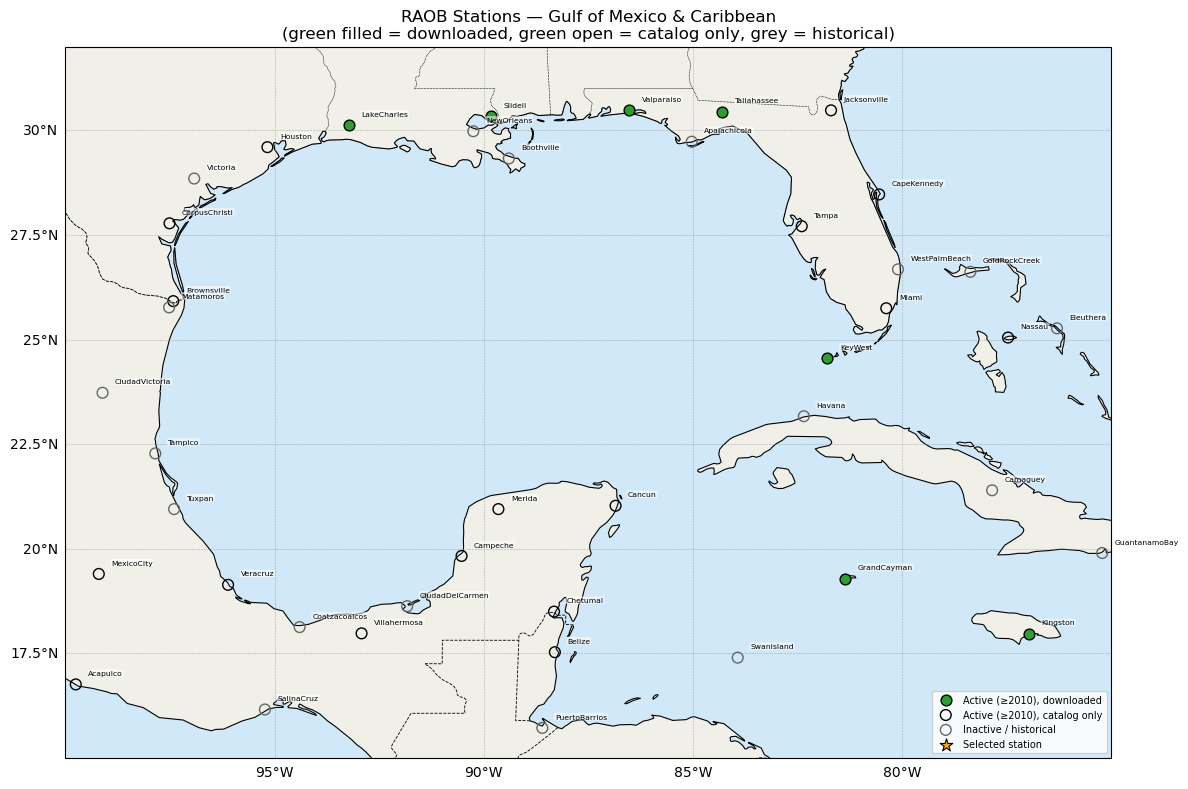

In [20]:
# ============================================================
# STATION MAP  —  Gulf of Mexico / Caribbean region
# ============================================================

importlib.reload(skutils)

import importlib
import gulf_caribbean_stations as gcs
importlib.reload(gcs)

dir_rdata_map = '/glade/work/rneale/data/raobs/'
dir_fig_map   = '/glade/u/home/rneale/python/python-figs/raobs/'

fig_map = skutils.plot_station_map(
    rdir             = dir_rdata_map,       # marks locally-downloaded stations
    station_catalog  = gcs.STATION_NAMES,   # all 68 known stations
    lat_range        = (15., 32.),
    lon_range        = (-100., -75.),
    highlight        = [station],           # orange star on current station
    title            = 'RAOB Stations — Gulf of Mexico & Caribbean\n'
                       '(green filled = downloaded, green open = catalog only, grey = historical)',
    dir_fig          = dir_fig_map,
    fname            = 'raob_station_map_gulf.png',
)
plt.show()
plt.close(fig_map)